# Portfolio analysis — `portfolioOptimizer`

Notebook companion to `main.py`. Same data, much nicer presentation: styled
DataFrames for transactions / positions / returns, drawdown statistics, the
TWR sub-period breakdown that goes into the chained TWR, and matplotlib
charts for the equity curve, drawdown, MWR cashflows, allocation, and
benchmark overlay.

All numbers come from the existing modules (`analytics/*`, `reporting/*`,
`domain/*`, `data/*`) — nothing is recomputed by hand.

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath('..'))

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.ticker import FuncFormatter

# Project imports — absolute paths now resolve because `..` is on sys.path.
from domain.transaction import Transaction
from domain.portfolio import Portfolio
from data.market_data import MarketDataFetcher
from analytics.timeseries import PortfolioTimeSeries
from analytics.performance import PerformanceCalculator
from analytics.twr import TWRcalculator
from analytics.mwr import MWRCalculator
from reporting.summary import PortfolioSummary

# ── Plot defaults (validated palette from the dataviz skill) ────────────
PALETTE = {
    'blue':    '#2a78d6',
    'orange':  '#eb6834',
    'aqua':    '#1baf7a',
    'yellow':  '#eda100',
    'magenta': '#e87ba4',
    'green':   '#008300',
    'violet':  '#4a3aa7',
    'red':     '#e34948',
    'ink':          '#0b0b0b',
    'ink_secondary':'#52514e',
    'hairline':     '#e1e0d9',
    'surface':      '#fcfcfb',
    'diverging_mid':'#f0efec',
    'good':         '#0ca30c',
    'critical':     '#d03b3b',
}
CATEGORICAL = [PALETTE['blue'], PALETTE['orange'], PALETTE['aqua'],
               PALETTE['yellow'], PALETTE['magenta'], PALETTE['green'],
               PALETTE['violet'], PALETTE['red']]

plt.rcParams.update({
    'figure.facecolor':  PALETTE['surface'],
    'axes.facecolor':    PALETTE['surface'],
    'axes.edgecolor':    PALETTE['hairline'],
    'axes.linewidth':    1.0,
    'axes.labelcolor':   PALETTE['ink_secondary'],
    'axes.titlecolor':   PALETTE['ink'],
    'xtick.color':       PALETTE['ink_secondary'],
    'ytick.color':       PALETTE['ink_secondary'],
    'grid.color':        PALETTE['hairline'],
    'grid.linewidth':    1.0,
    'grid.linestyle':    '-',
    'font.size':         10,
    'axes.titlesize':    12,
    'axes.spines.top':   False,
    'axes.spines.right': False,
})

pd.set_option('display.float_format', lambda v: f'{v:,.4f}' if abs(v) >= 1 else f'{v:.4%}' if abs(v) < 1 else f'{v:,.2f}')

# Helper to format axis ticks as currency.
def currency_fmt(x, _pos):
    return f'${x:,.0f}'

def pct_fmt(x, _pos):
    return f'{x:.0%}'

In [2]:
# ── Build the same sample portfolio that main.py uses ──────────────────
t1 = Transaction('aapl', '2024-01-02', 'BUY', 5, 185, 2, 'USD')
t2 = Transaction('msft', '2024-03-01', 'BUY', 3, 415, 2, 'USD')
t3 = Transaction('aapl', '2025-01-02', 'SELL', 3, 185, 2, 'USD')

port1 = Portfolio("ATK_1", "USD", creation_date='2024-01-01')
for tx in (t1, t2, t3):
    port1.add_transaction(tx)

fetcher = MarketDataFetcher()
time_s = PortfolioTimeSeries(port1, fetcher=fetcher, start_date=None)
value = time_s.portfolio_value()
returns = time_s.portfolio_returns()
perf = PerformanceCalculator(portfolio_value=value, portfolio_returns=returns)
port_positions = port1.open_positions()
twr = TWRcalculator(value, port_positions)
twr_total = twr.calculate_twr()  # populates twr.sub_periods as a side effect
mwr = MWRCalculator(
    cashflows=time_s.mwr_cashflows,
    current_value=value.iloc[-1],
    inception_date=pd.Timestamp(port1.creation_date),
)
mwr_total = mwr.calculate_mwr()

print(f'Portfolio value range: {value.index.min().date()} → {value.index.max().date()} ({len(value):,} trading days)')
print(f'Current value: ${value.iloc[-1]:,.2f}')
print(f'TWR: {twr_total:.2%}    MWR: {mwr_total:.2%}    Sharpe: {perf.sharpe_ratio():.3f}    Max DD: {perf.max_drawdown():.2%}')

Portfolio value range: 2024-01-02 → 2026-08-05 (677 trading days)
Current value: $2,097.19
TWR: 24.17%    MWR: 9.67%    Sharpe: 0.409    Max DD: -46.43%


## 1 · Transactions & Positions

In [3]:
transactions_df = pd.DataFrame([{
    'date':     tx.transaction_date,
    'ticker':   tx.ticker,
    'type':     tx.transaction_type,
    'quantity': tx.quantity,
    'price':    tx.cost_per_unit,
    'fees':     tx.fees,
    'total':    tx.total_cost,
    'ccy':      tx.currency,
} for tx in (t1, t2, t3)])
transactions_df['date'] = pd.to_datetime(transactions_df['date'])
transactions_df = transactions_df.sort_values('date').reset_index(drop=True)
transactions_df

,date,ticker,type,quantity,price,fees,total,ccy
0,2024-01-02,AAPL,BUY,5,185,2,927,USD
1,2024-03-01,MSFT,BUY,3,415,2,1247,USD
2,2025-01-02,AAPL,SELL,3,185,2,553,USD


In [4]:
positions_df = pd.DataFrame([{
    'ticker':      pos.ticker,
    'quantity':    pos.net_quantity,
    'avg_cost':    pos.average_cost_basis,
    'is_open':     pos.is_open,
    'opened_on':   pos.opening_date,
} for pos in port1.all_positions()])
positions_df

,ticker,quantity,avg_cost,is_open,opened_on
0,AAPL,2,185.0000,True,2024-01-02
1,MSFT,3,415.0000,True,2024-03-01


## 2 · Portfolio Value, Returns & Drawdown

In [5]:
print('Head — first 5 trading days')
display(value.head().to_frame('portfolio_value'))
print('\nTail — last 5 trading days')
display(value.tail().to_frame('portfolio_value'))
print('\nSummary statistics')
display(value.describe().to_frame('portfolio_value'))

drawdown = value / value.cummax() - 1
print('\nDrawdown summary')
display(drawdown.describe().to_frame('drawdown'))

Head — first 5 trading days


,portfolio_value
2024-01-02,917.8110
2024-01-03,910.9386
2024-01-04,899.3696
2024-01-05,895.7606
2024-01-08,917.4155



Tail — last 5 trading days


,portfolio_value
2026-07-30,"2,020.1600"
2026-07-31,"2,011.9800"
2026-08-03,"2,069.7900"
2026-08-04,"2,097.1900"
2026-08-05,"2,097.1900"



Summary statistics


,portfolio_value
count,677.0000
mean,"1,922.5791"
std,374.6182
min,894.7750
25%,"1,733.1548"
50%,"1,952.3330"
75%,"2,143.1569"
max,"2,606.7499"



Drawdown summary


,drawdown
count,677.0000
mean,-19.8588%
std,13.7627%
min,-46.4335%
25%,-31.8385%
50%,-23.4994%
75%,-5.2307%
max,0.0000%


C:\Users\STEEL CO\AppData\Local\Temp\ipykernel_23400\1150756601.py:44: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout(rect=(0, 0, 1, 0.96))


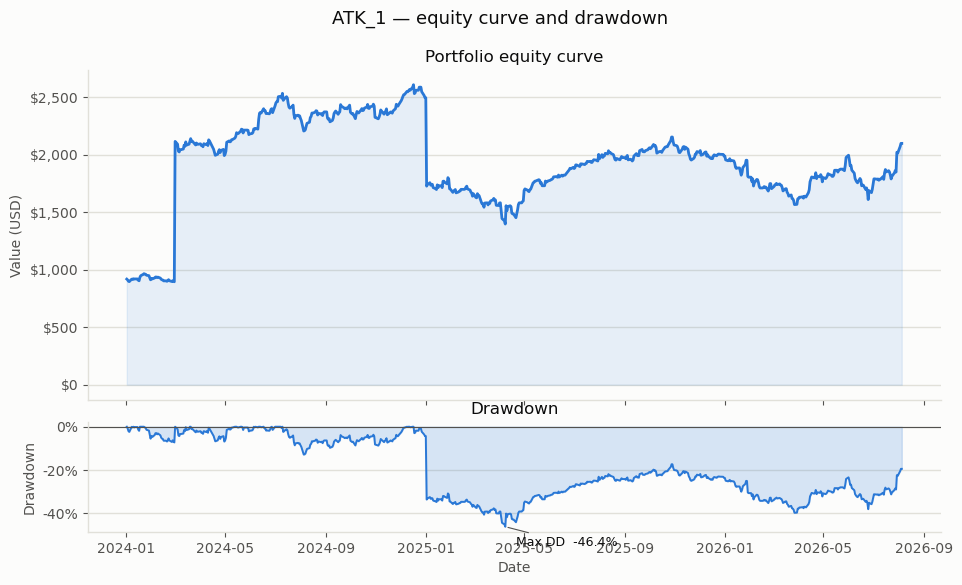

In [6]:
# Equity curve + drawdown — single axis (no dual-axis!), two stacked panels.
fig, (ax_value, ax_dd) = plt.subplots(
    2, 1, figsize=(11, 6), sharex=True,
    gridspec_kw={'height_ratios': [3, 1], 'hspace': 0.10},
)

# Equity curve
ax_value.fill_between(value.index, value.values, 0,
                       color=PALETTE['blue'], alpha=0.10)
ax_value.plot(value.index, value.values,
               color=PALETTE['blue'], linewidth=2.0, label='Portfolio value')
ax_value.yaxis.set_major_formatter(FuncFormatter(currency_fmt))
ax_value.set_title('Portfolio equity curve')
ax_value.set_ylabel('Value (USD)')
ax_value.grid(True, axis='y')
ax_value.set_axisbelow(True)

# Drawdown uses diverging blue↔red, anchored at the gray midpoint.
dd_values = drawdown.values
ax_dd.fill_between(drawdown.index, dd_values, 0,
                   where=(dd_values <= 0),
                   color=PALETTE['blue'], alpha=0.18,
                   interpolate=True, label='Drawdown')
ax_dd.plot(drawdown.index, dd_values,
           color=PALETTE['blue'], linewidth=1.4)
ax_dd.axhline(0, color=PALETTE['ink_secondary'], linewidth=0.8)
ax_dd.yaxis.set_major_formatter(FuncFormatter(pct_fmt))
ax_dd.set_title('Drawdown')
ax_dd.set_ylabel('Drawdown')
ax_dd.grid(True, axis='y')
ax_dd.set_axisbelow(True)
ax_dd.set_xlabel('Date')

# Selective direct label: the worst drawdown point.
worst_idx = drawdown.idxmin()
worst_val = drawdown.loc[worst_idx]
ax_dd.annotate(f'Max DD  {worst_val:.1%}',
               xy=(worst_idx, worst_val),
               xytext=(8, -14), textcoords='offset points',
               color=PALETTE['ink'], fontsize=9,
               arrowprops=dict(arrowstyle='-', color=PALETTE['ink_secondary'], lw=0.8))

fig.suptitle('ATK_1 — equity curve and drawdown', fontsize=13, color=PALETTE['ink'])
fig.tight_layout(rect=(0, 0, 1, 0.96))
plt.show()

## 3 · Performance, TWR sub-periods, MWR cash flows

In [7]:
performance_df = pd.DataFrame({
    'value': [
        perf.total_return(),
        perf.annualized_return(),
        perf.volatility(),
        perf.sharpe_ratio(),
        perf.max_drawdown(),
        twr_total,
        mwr_total,
    ],
}, index=[
    'Total return',
    'Annualized return',
    'Volatility (annualized)',
    'Sharpe ratio',
    'Max drawdown',
    'Time-weighted return',
    'Money-weighted return (IRR)',
])
performance_df

,value
Total return,1.2850
Annualized return,36.0772%
Volatility (annualized),88.2182%
Sharpe ratio,40.8954%
Max drawdown,-46.4335%
Time-weighted return,24.1708%
Money-weighted return (IRR),9.6661%


In [8]:
# TWR sub-period breakdown. TWRcalculator.calculate_twr() populated twr.sub_periods.
sub_returns = []
for i in range(len(twr.sub_periods) - 1):
    s, e = twr.sub_periods[i], twr.sub_periods[i + 1]
    sub_returns.append({
        'from':     pd.Timestamp(s).date(),
        'to':       pd.Timestamp(e).date(),
        'days':     (pd.Timestamp(e) - pd.Timestamp(s)).days,
        'subperiod_return': twr._calculate_subperiod_returns(s, e),
    })
twr_sub_df = pd.DataFrame(sub_returns)
print('TWR sub-periods (the product of (1 + subperiod_return) is the chained TWR above)')
display(twr_sub_df)

TWR sub-periods (the product of (1 + subperiod_return) is the chained TWR above)


,from,to,days,subperiod_return
0,2024-01-02,2024-03-01,59,-5.2765%
1,2024-03-01,2025-01-02,307,7.8623%
2,2025-01-02,2026-08-05,580,21.5324%


In [9]:
# MWR cash flows. MWRCalculator mutated its input in __init__;
# time_s.mwr_cashflows is the original (date, amount) list as built from transactions.
cf_df = pd.DataFrame(time_s.mwr_cashflows, columns=['date', 'amount'])
cf_df['kind'] = np.where(cf_df['amount'] < 0, 'BUY (cash out)', 'SELL (cash in)')
cf_df = cf_df.sort_values('date').reset_index(drop=True)
cf_df

,date,amount,kind
0,2024-01-02,-927,BUY (cash out)
1,2024-03-01,-1247,BUY (cash out)
2,2025-01-02,553,SELL (cash in)


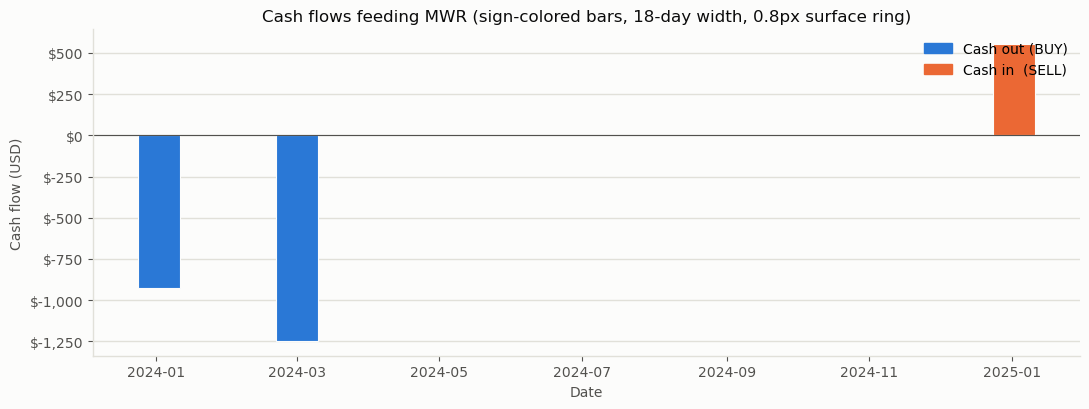

In [10]:
# MWR cashflow bar chart — color by sign.
fig, ax = plt.subplots(figsize=(11, 4.2))
colors = np.where(cf_df['amount'] < 0, PALETTE['blue'], PALETTE['orange'])
ax.bar(cf_df['date'], cf_df['amount'], color=colors, width=18,
       edgecolor=PALETTE['surface'], linewidth=0.8)
ax.axhline(0, color=PALETTE['ink_secondary'], linewidth=0.8)
ax.yaxis.set_major_formatter(FuncFormatter(currency_fmt))
ax.set_title('Cash flows feeding MWR (sign-colored bars, 18-day width, 0.8px surface ring)')
ax.set_xlabel('Date')
ax.set_ylabel('Cash flow (USD)')
ax.grid(True, axis='y')
ax.set_axisbelow(True)

from matplotlib.patches import Patch
ax.legend(handles=[
    Patch(color=PALETTE['blue'],   label='Cash out (BUY)'),
    Patch(color=PALETTE['orange'], label='Cash in  (SELL)'),
], frameon=False, loc='upper right')
fig.tight_layout()
plt.show()

## 4 · Allocation summary

In [11]:
# Build a current allocation table from the existing position objects.
alloc_rows = []
total_value = 0.0
for pos in port1.all_positions():
    last_price = time_s.build_price_frames().loc[value.index.max(), pos.ticker]
    mv = last_price * pos.net_quantity
    total_value += mv
    alloc_rows.append({
        'ticker':   pos.ticker,
        'qty':      pos.net_quantity,
        'avg_cost': pos.average_cost_basis,
        'last_price': last_price,
        'market_value': mv,
    })
alloc_df = pd.DataFrame(alloc_rows)
alloc_df['weight'] = alloc_df['market_value'] / total_value
alloc_df = alloc_df.sort_values('weight', ascending=False).reset_index(drop=True)
display(alloc_df)

,ticker,qty,avg_cost,last_price,market_value,weight
0,MSFT,3,415.0000,492.8100,"1,478.4300",70.4958%
1,AAPL,2,185.0000,309.3800,618.7600,29.5042%


C:\Users\STEEL CO\AppData\Local\Temp\ipykernel_23400\2732970175.py:43: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout(rect=(0, 0, 1, 0.95))


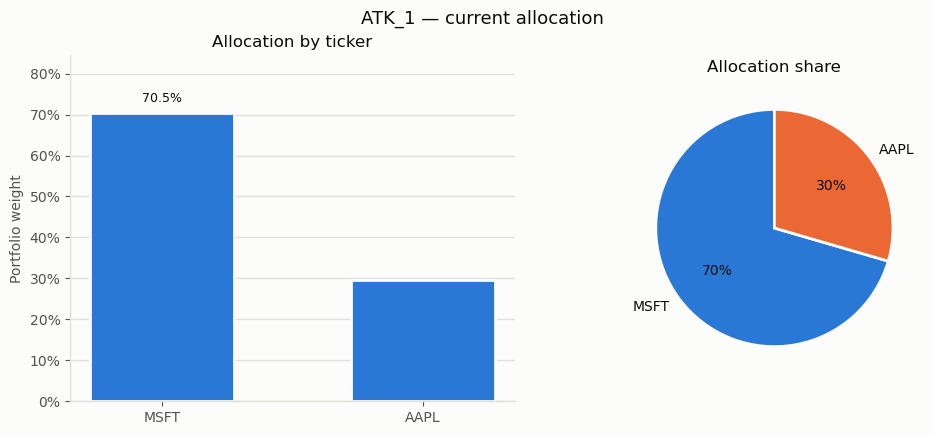

In [12]:
# Bar + pie on the same figure — bar gives precise comparison, pie gives
# at-a-glance part-of-whole. Two charts, not a dual-axis chart.
fig, (ax_bar, ax_pie) = plt.subplots(1, 2, figsize=(11, 4.5),
                                      gridspec_kw={'width_ratios': [3, 2], 'wspace': 0.30})

# Bar — one series, one color (categorical slot 1 = blue).
bars = ax_bar.bar(alloc_df['ticker'].str.upper(),
                  alloc_df['weight'],
                  color=PALETTE['blue'],
                  width=0.55, edgecolor=PALETTE['surface'], linewidth=2)
ax_bar.yaxis.set_major_formatter(FuncFormatter(pct_fmt))
ax_bar.set_title('Allocation by ticker')
ax_bar.set_ylabel('Portfolio weight')
ax_bar.set_ylim(0, alloc_df['weight'].max() * 1.20)
ax_bar.grid(True, axis='y')
ax_bar.set_axisbelow(True)

# Selective direct labels — only on the largest bar (the story).
top = alloc_df.iloc[0]
ax_bar.annotate(f'{top["weight"]:.1%}',
                xy=(0, top['weight']),
                xytext=(0, 8), textcoords='offset points',
                ha='center', color=PALETTE['ink'], fontsize=9)

# Pie — at most a handful of segments; otherwise fall back to a bar.
if len(alloc_df) <= 6:
    pie_colors = CATEGORICAL[:len(alloc_df)]
    ax_pie.pie(alloc_df['weight'],
               labels=alloc_df['ticker'].str.upper(),
               colors=pie_colors,
               startangle=90,
               autopct=lambda v: f'{v:.0f}%' if v >= 5 else '',
               wedgeprops={'edgecolor': PALETTE['surface'], 'linewidth': 2},
               textprops={'color': PALETTE['ink']})
    ax_pie.set_title('Allocation share')
else:
    ax_pie.text(0.5, 0.5,
                'Too many tickers for a pie\n— see the bar chart.',
                ha='center', va='center', color=PALETTE['ink_secondary'])
    ax_pie.set_axis_off()

fig.suptitle('ATK_1 — current allocation', fontsize=13, color=PALETTE['ink'])
fig.tight_layout(rect=(0, 0, 1, 0.95))
plt.show()

## 5 · Benchmark comparison

In [13]:
# Use the existing PortfolioSummary to get benchmark numbers — don't recompute.
ps = PortfolioSummary(portfolio=port1, fetcher=fetcher, benchmark_ticker='SPY')
summary = ps.get_summary()
bench_block = summary['benchmark']

bench_df = pd.DataFrame({
    'value': [
        bench_block['alpha'],
        bench_block['beta'],
        bench_block['correlation'],
        bench_block['tracking_error'],
        bench_block['information_ratio'],
        bench_block['outperformance'],
        bench_block['benchmark_return'],
    ],
}, index=[
    'Alpha (annualized)',
    'Beta',
    'Correlation',
    'Tracking error (annualized)',
    'Information ratio',
    'Outperformance (vs SPY)',
    'Benchmark return (cumulative)',
])
display(bench_df)

c:\Users\STEEL CO\portfolioOptimizer\portfolioOptimizer\data\market_data.py:91: FutureWarning: YF.download() has changed argument auto_adjust default to True
  dat = yf.download(ticker, start=start_date, end=end_date)


Cache expired for SPY. Fetching fresh data...


[*********************100%***********************]  1 of 1 completed


,value
Alpha (annualized),31.5236%
Beta,1.1705
Correlation,20.6229%
Tracking error (annualized),21.2893%
Information ratio,35.7376%
Outperformance (vs SPY),60.3835%
Benchmark return (cumulative),68.1156%


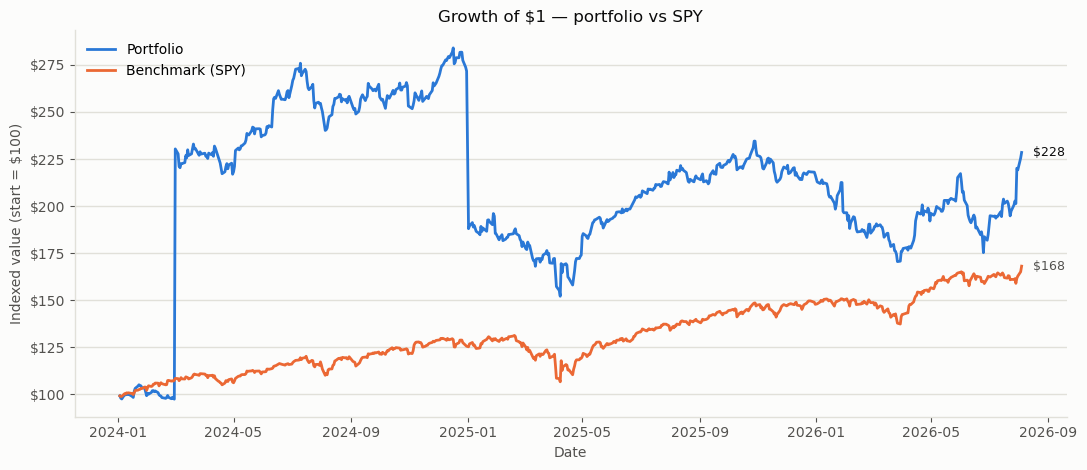

In [14]:
# Benchmark overlay — index both to a common base (=100 at the first observation)
# so two series of different scale fit on ONE axis. This is the explicit fix
# for the "dual-axis chart" anti-pattern.
port_growth = summary['timeseries']['growth_of_1usd']
bench_growth = bench_block['growth_of_1usd_benchmark']
common = port_growth.index.intersection(bench_growth.index)
port_g = port_growth.loc[common]
bench_g = bench_growth.loc[common]

fig, ax = plt.subplots(figsize=(11, 4.8))
ax.plot(port_g.index, port_g.values,
        color=PALETTE['blue'], linewidth=2.0, label='Portfolio')
ax.plot(bench_g.index, bench_g.values,
        color=PALETTE['orange'], linewidth=2.0, label=f"Benchmark ({bench_block['benchmark_ticker']})")
ax.yaxis.set_major_formatter(FuncFormatter(lambda v, _: f'${v:,.0f}'))
ax.set_title('Growth of $1 — portfolio vs SPY')
ax.set_xlabel('Date')
ax.set_ylabel('Indexed value (start = $100)')
ax.grid(True, axis='y')
ax.set_axisbelow(True)
ax.legend(frameon=False, loc='upper left')

# Selective direct labels at the right edge.
ax.annotate(f'${port_g.iloc[-1]:,.0f}',
            xy=(port_g.index[-1], port_g.iloc[-1]),
            xytext=(8, 0), textcoords='offset points',
            color=PALETTE['ink'], fontsize=9, va='center')
ax.annotate(f'${bench_g.iloc[-1]:,.0f}',
            xy=(bench_g.index[-1], bench_g.iloc[-1]),
            xytext=(8, 0), textcoords='offset points',
            color=PALETTE['ink_secondary'], fontsize=9, va='center')

fig.tight_layout()
plt.show()

---

All numbers above are produced by the existing `reporting.summary.PortfolioSummary.get_summary()` aggregator (and the underlying calculators in `analytics/`). The notebook is a viewer, not a re-implementation."